In [2]:
# DOI analysis
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from matplotlib import patches
import random
from scipy.optimize import curve_fit
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}

# Hardcode indices
rough5micron_indices = [126, 102, 77, 79, 122, 91, 70, 72]
rough28micron_indices = [119, 118, 124, 115, 127, 117, 113, 111]
rough14micron_indices = [65, 64, 85, 80, 84, 82, 86, 81]
unpolished_indices = [x for x in range(64, 128) if x not in rough5micron_indices and x not in rough14micron_indices and x not in rough28micron_indices]
indices_list = [unpolished_indices, rough5micron_indices, rough14micron_indices, rough28micron_indices]

# Define valid index pairs in DOI crystals
index_pairs = []
for i in range(64, 128):
    coord = indices[i]
    # find the dictionary key with value (coord[0], 7-coord[1])
    other = next(k for k, v in indices.items() if v == (coord[0], 7-coord[1]))
    index_pairs.append((i, other))

print(index_pairs)

def get_compliment(index):
    # Get the second index of the pair with the given index as the first index
    return next(pair[1] for pair in index_pairs if pair[0] == index)

[(64, 127), (65, 117), (66, 75), (67, 115), (68, 73), (69, 119), (70, 121), (71, 120), (72, 118), (73, 68), (74, 124), (75, 66), (76, 123), (77, 114), (78, 125), (79, 116), (80, 113), (81, 110), (82, 112), (83, 108), (84, 109), (85, 111), (86, 106), (87, 104), (88, 107), (89, 103), (90, 105), (91, 122), (92, 101), (93, 100), (94, 98), (95, 99), (96, 97), (97, 96), (98, 94), (99, 95), (100, 93), (101, 92), (102, 126), (103, 89), (104, 87), (105, 90), (106, 86), (107, 88), (108, 83), (109, 84), (110, 81), (111, 85), (112, 82), (113, 80), (114, 77), (115, 67), (116, 79), (117, 65), (118, 72), (119, 69), (120, 71), (121, 70), (122, 91), (123, 76), (124, 74), (125, 78), (126, 102), (127, 64)]


In [3]:
# Read in data
paths = [
    '/home/kale-chen/Documents/PET/DOI/f15mm.dat',
    '/home/kale-chen/Documents/PET/DOI/3xf15mm.dat'
]
doi_data = []
names = []
distances = []
for path in paths:
    df = pd.read_csv(path, sep = '\t', header=None)
    print(df.shape)
    df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
    data = np.asarray(df, dtype = np.float32)
    print(data)
    doi_data.append(data)
    names.append(path.split('/')[-1].split('.')[0])
    #distances.append(int(path.split('/')[-1].split('.')[0].split('mm')[0][1:]))
filtered_doi_data = doi_data

(73226, 15)
[[ 27.436653 768.        17.325607 471.        16.586437 104.      ]
 [ 10.987434 860.        15.93364  497.        19.207096  80.      ]
 [  3.369541 791.        16.2691   483.        15.454788  95.      ]
 ...
 [ 31.021446 852.        22.560112 492.        24.500916  83.      ]
 [ 17.728592 818.         2.281265 477.         2.212208 100.      ]
 [ 18.429695 873.         3.785088 510.         4.587811 102.      ]]
(10485, 15)
[[ 29.370193 869.        15.407932 477.        14.517941 100.      ]
 [ 19.037598 886.         7.670872 504.         8.796234  71.      ]
 [  5.997097 841.        27.618904 490.        19.430706  86.      ]
 ...
 [ 30.991646 856.        13.595673 456.        20.490654 118.      ]
 [ 17.009018 475.         2.437389  91.         2.437389  91.      ]
 [ 32.87918  882.        16.96851  499.        17.980206  67.      ]]


In [3]:
# Filter each dataset in doi_data for columns with highest activity in opposite module, "digital collimator"
module_ids = [k for k, v in indices.items() if v[1] in (1, 2, 3)]
filtered_doi_data = []
for dat in doi_data:
    filtered_data = dat[np.isin(dat[:, 1] - 768, module_ids)]
    filtered_doi_data.append(filtered_data)
    print(f"Original: {len(dat)}, Filtered: {len(filtered_data)}")

Original: 73226, Filtered: 37529
Original: 10485, Filtered: 4685


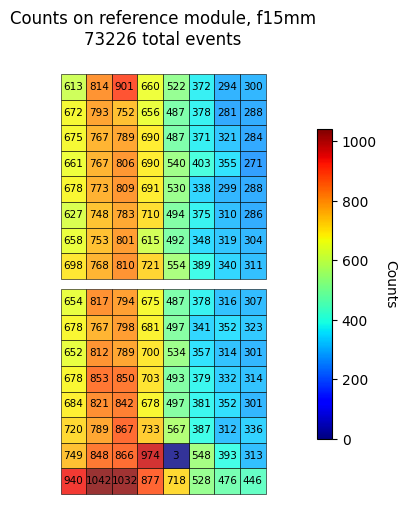

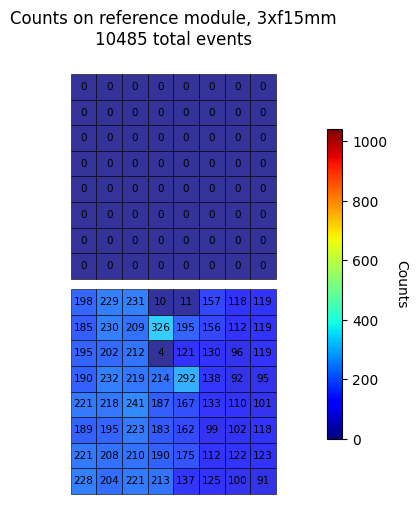

In [8]:
event_counts_list = []
max_vals = []

for dat in filtered_doi_data:
    ids = np.asarray(dat[:, 1] % 128, dtype=np.int32)
    event_counts = np.zeros((128), dtype=np.int32)
    np.add.at(event_counts, ids, 1)
    event_counts_list.append(event_counts)
    max_vals.append(np.max(event_counts))

max_vals = np.asarray(max_vals)
max_val = np.max(max_vals)


def get_color(val):
    return plt.cm.jet(val / max_val)

figs = []
for i in range(len(event_counts_list)):
    fig, ax = plt.subplots(figsize=(4, 6))
    for n in range(0, 128):
        # Use the indices dictionary to get positions
        if n in indices:
            y, x = indices[n]
            y = 15 - y
            if y >= 8:
                y += 0.4
            color_val = plt.cm.jet(event_counts_list[i][n] / max_val)
            rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=color_val, alpha=0.8)
            ax.add_patch(rect)
            ax.text(x + 0.5, y + 0.5, event_counts_list[i][n], fontsize=7.5, ha='center', va='center')
        else:
            continue

    plt.tick_params(axis='both', which='both', bottom=False, top=False,
                    left=False, right=False, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.ylim(0, 16)
    plt.xlim(0, 8)
    plt.axis('equal')
    
    # Add colorbar
    sm = ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(vmin=0, vmax=max_val))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label('Counts', rotation=270, labelpad=15)
    
    plt.title(f'Counts on reference module, {names[i]}\n{np.sum(event_counts_list[i])} total events')
    plt.show()
    figs.append(fig)

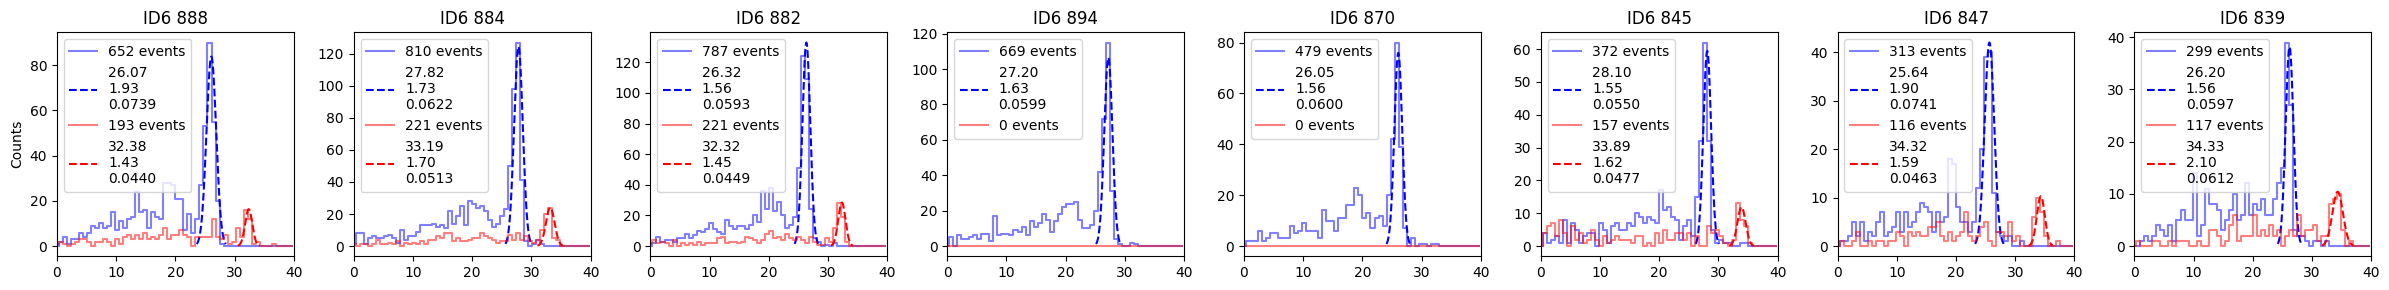

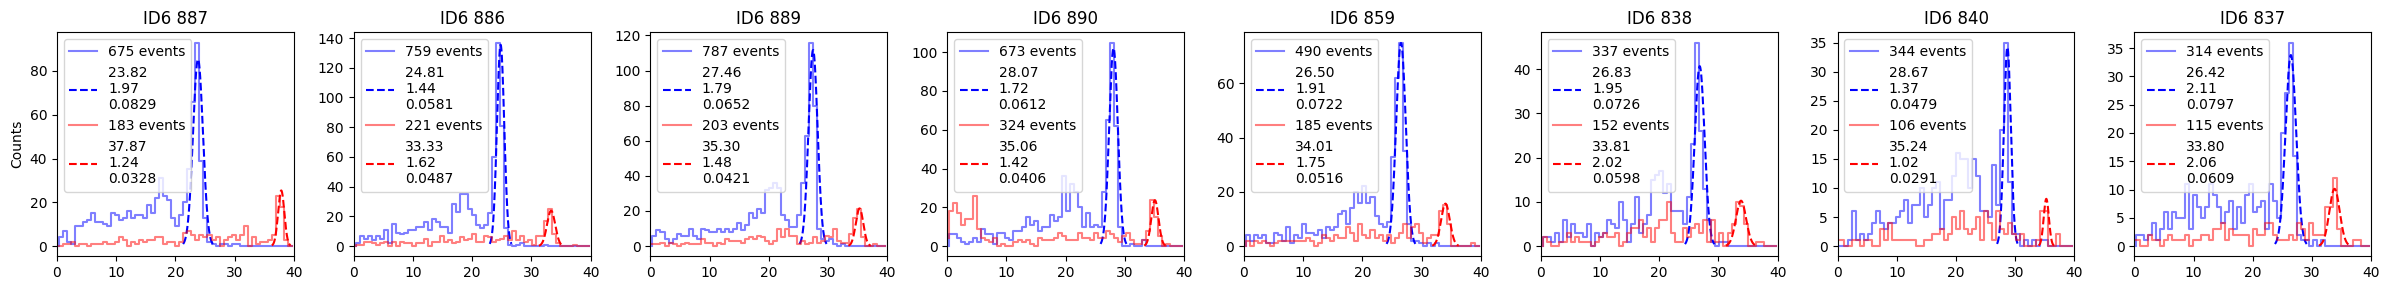

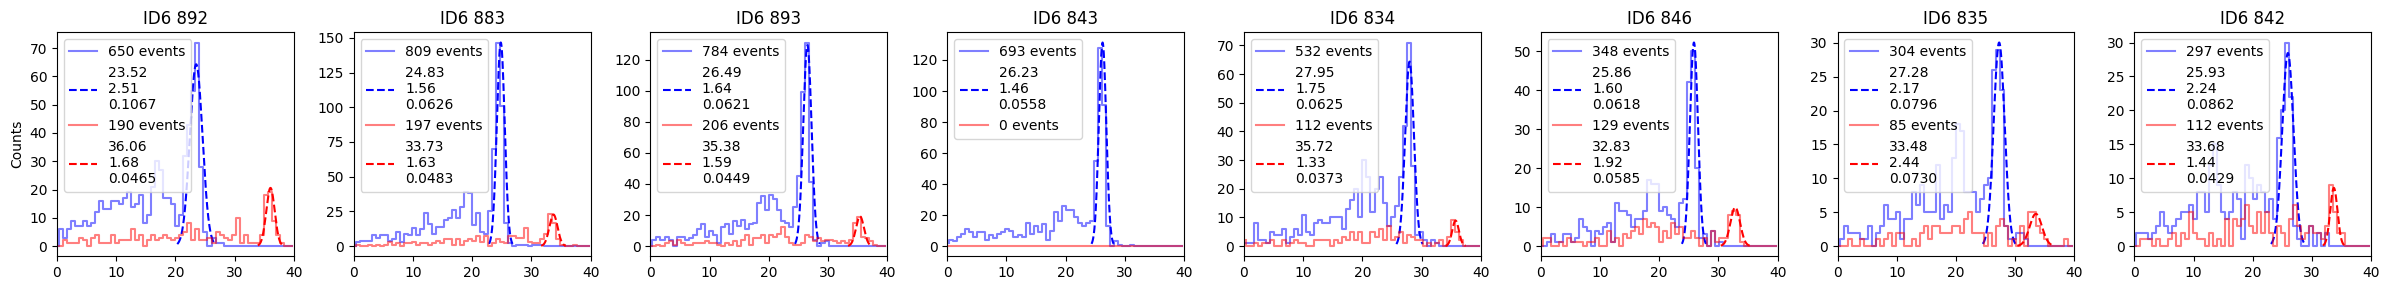

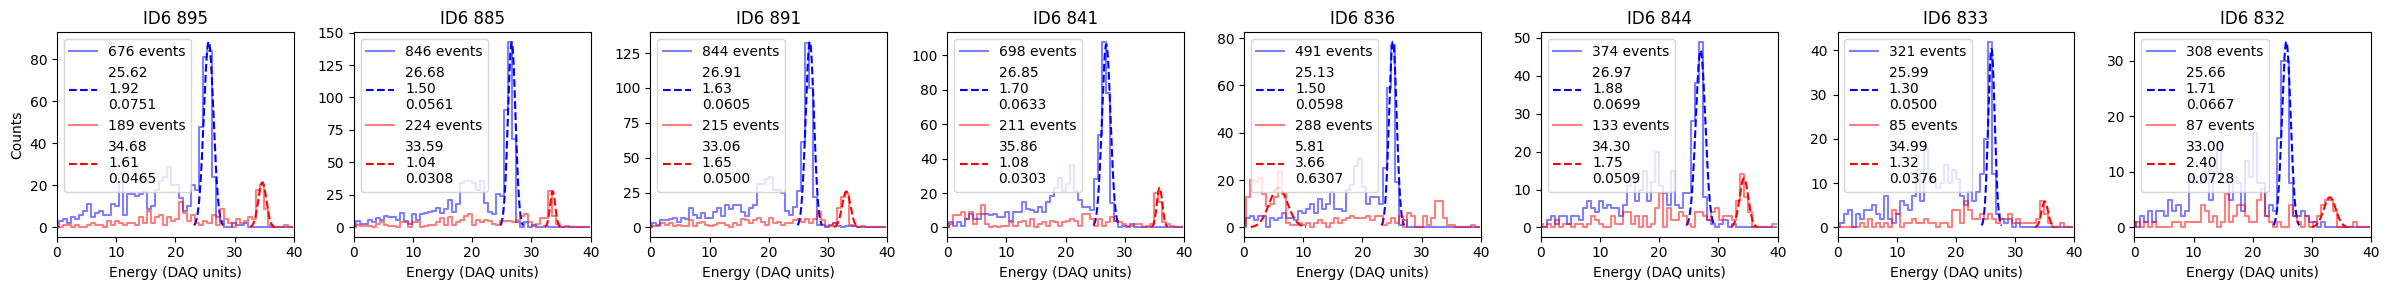

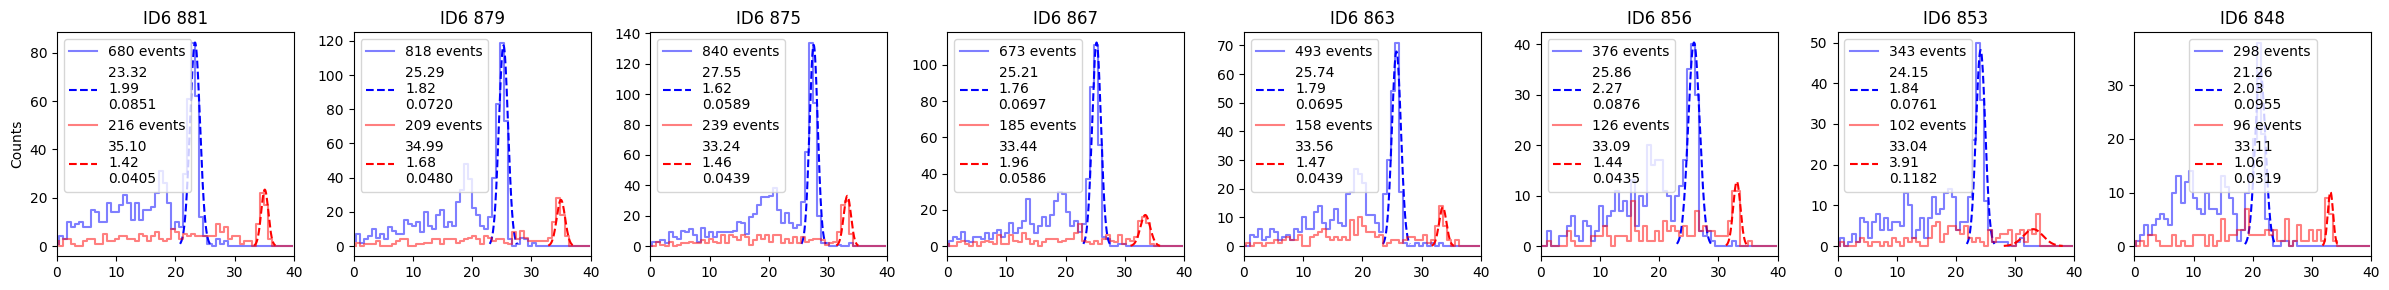

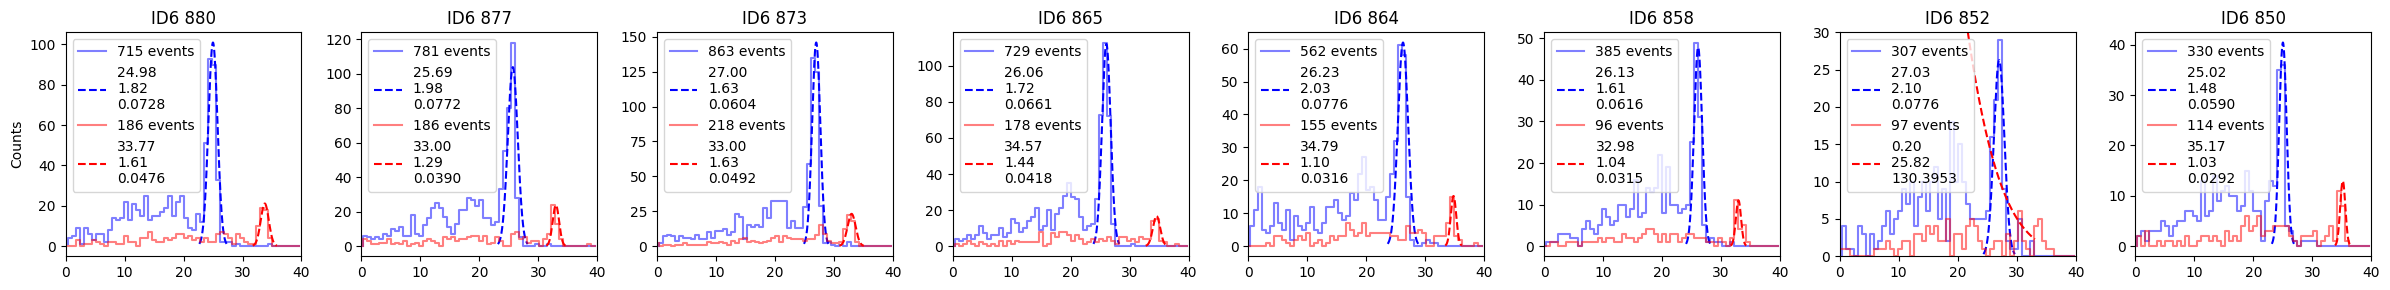

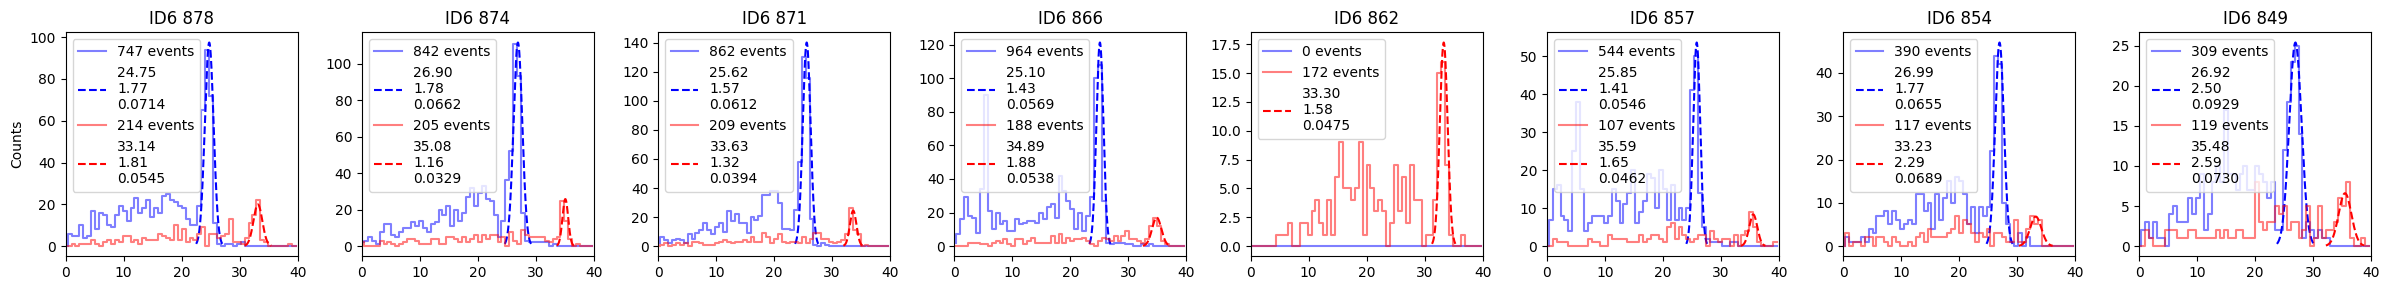

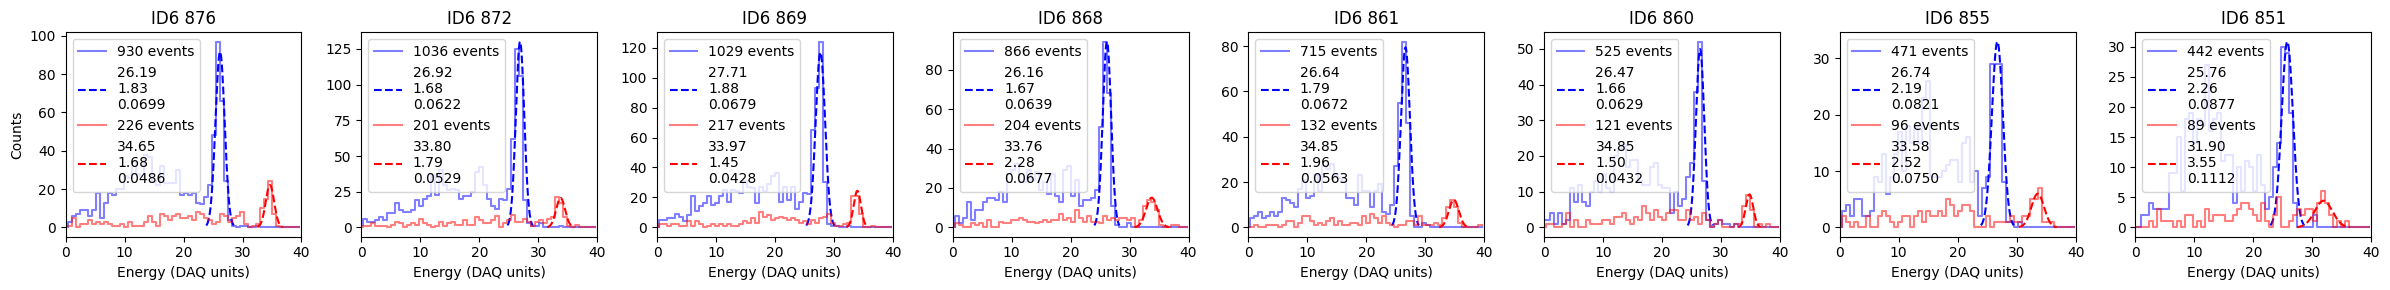

In [9]:
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if hist[-1*i] >= 0.5 * np.max(hist):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1]
    fit_x = list(bins[photopeak-5:photopeak+10])
    fit_y = list(hist[photopeak-5:photopeak+10])

    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, fit_co = curve_fit(gaussian, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2])
        except:
            print(f'Photopeak fit failed {id}')
    return fit_p



colors = ['blue', 'red']
norm_factors = [len(filtered_doi_data[0]) / len(filtered_doi_data[x]) for x in range(len(filtered_doi_data))]
bins = np.linspace(0, 40, 60)
bincenters = (bins[:-1] + bins[1:]) / 2

eres = [[] for _ in range(len(filtered_doi_data))]

for row in range(8, 16):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    list_indices = list(list_indices.keys())
    fig, subplots = plt.subplots(1, 8, figsize=(24, 3))
    subplots = subplots.flatten()
    for i in range(8):
        id6 = list_indices[i] + 768
        for dat, color, norm_factor, n in zip(filtered_doi_data, colors, norm_factors, range(len(filtered_doi_data))):
            energies6 = dat[:, 0][dat[:, 1] == id6]
            hist, _ = np.histogram(energies6, bins=bins, range=(0, 40))
            subplots[i].step(bincenters, hist, color=color, alpha=0.5, label = f'{np.sum(hist)} events')
            if len(energies6) > 0:
                fit_p = findPhotopeak(hist, bincenters)
                plotting_bounds = np.linspace(fit_p[1] - 3 * fit_p[2], fit_p[1] + 3 * fit_p[2], 1000)
                fwhm = fit_p[2]*2.355
                energy_resolution = fwhm / fit_p[1]
                subplots[i].plot(plotting_bounds, gaussian(plotting_bounds, *fit_p), color=color, linestyle='--', label=f'{fit_p[1]:.2f}\n{fwhm:.2f}\n{energy_resolution:.4f}')
                eres[n].append(energy_resolution)
             
        subplots[i].set_title(f'ID6 {id6}')
        subplots[i].legend()
       
    for i in range(8):
        subplots[i].set_xlim(0, 40)
        if list_indices[i] + 768 == 852:
            subplots[i].set_ylim(0, 30)
        if i % 8 == 0:
            subplots[i].set_ylabel('Counts')
        if row % 4 == 3:
            subplots[i].set_xlabel('Energy (DAQ units)')

    plt.tight_layout()
    plt.show()
            

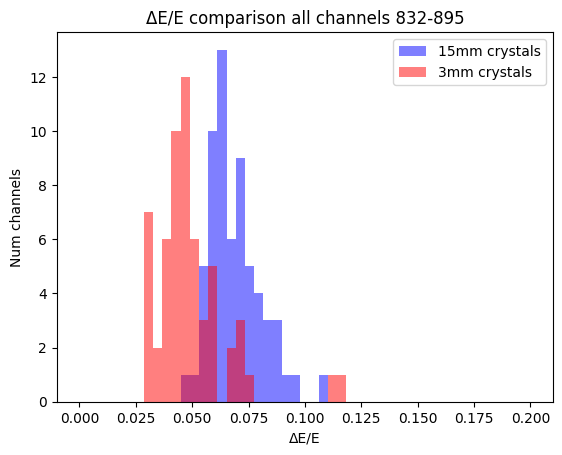

In [25]:
bins = np.linspace(0, 0.2, 50)
bincenters = (bins[:-1] + bins[1:]) / 2

hist, bins = plt.hist(eres[0], bins=bins, range=(0, 0.2), color='blue', alpha=0.5, label='15mm crystals')[0:2]
popt, _ = curve_fit(gaussian, bincenters, hist, p0=[np.max(hist), bincenters[np.argmax(hist)], 0.01])
plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
#plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color='blue', linestyle='--', label=f'{popt[1]:.2f}\n{popt[2]*2.355:.2f}\n{popt[1]/popt[2]*2.355:.4f}')
plt.hist(eres[1], bins=bins, range=(0, 0.2), color='red', alpha=0.5, label='3mm crystals')
plt.legend()
plt.title('ΔE/E comparison all channels 832-895')
plt.xlabel('ΔE/E')
plt.ylabel('Num channels')
plt.show()

In [41]:
# Read in data for time difference analysis
doi_data = []
names = []
distances = []
for path in paths:
    df = pd.read_csv(path, sep = '\t', header=None)
    print(df.shape)
    reftime = df.iloc[:, 2] / 1000000000000
    t1 = df.iloc[:,12] - df.iloc[:,2]
    t2 = df.iloc[:,7] - df.iloc[:,2]
    print(reftime.dtype, t1.dtype, t2.dtype)
    df = df.iloc[:, [3, 4, 8, 9, 13, 14]]
    data = np.asarray(df, dtype = np.float32)
    data = np.column_stack((data, reftime, t1, t2))
    print(data)
    doi_data.append(data)
    names.append(path.split('/')[-1].split('.')[0])
    #distances.append(int(path.split('/')[-1].split('.')[0].split('mm')[0][1:]))

filter_data = True
module_ids = [k for k, v in indices.items() if v[1] in (1, 2, 3)]
filtered_doi_data = []
for dat in doi_data:
    if filter_data:
        filtered_data = dat[np.isin(dat[:, 1] - 768, module_ids)]
        filtered_doi_data.append(filtered_data)
        print(f"Original: {len(dat)}, Filtered: {len(filtered_data)}")
    else:
        filtered_doi_data.append(dat)

(73226, 15)
float64 int64 int64
[[ 2.74366531e+01  7.68000000e+02  1.73256073e+01 ...  6.59263986e+00
   7.89000000e+02 -1.07000000e+02]
 [ 1.09874344e+01  8.60000000e+02  1.59336395e+01 ...  6.64181531e+00
  -1.15900000e+03 -1.25000000e+02]
 [ 3.36954093e+00  7.91000000e+02  1.62691002e+01 ...  6.79872871e+00
  -1.55800000e+03 -5.86000000e+02]
 ...
 [ 3.10214462e+01  8.52000000e+02  2.25601120e+01 ...  5.40613875e+03
   5.21200000e+03  6.11600000e+03]
 [ 1.77285919e+01  8.18000000e+02  2.28126502e+00 ...  5.40618274e+03
   1.73400000e+03  2.41600000e+03]
 [ 1.84296951e+01  8.73000000e+02  3.78508806e+00 ...  5.40636715e+03
   6.30000000e+02  1.28200000e+03]]
(10485, 15)
float64 int64 int64
[[ 2.93701935e+01  8.69000000e+02  1.54079323e+01 ...  6.71558512e+00
   9.00000000e+01 -5.13000000e+02]
 [ 1.90375977e+01  8.86000000e+02  7.67087221e+00 ...  7.03986839e+00
  -8.05000000e+02  8.00000000e+02]
 [ 5.99709702e+00  8.41000000e+02  2.76189041e+01 ...  8.16853061e+00
   6.30600000e+03  6

189
51


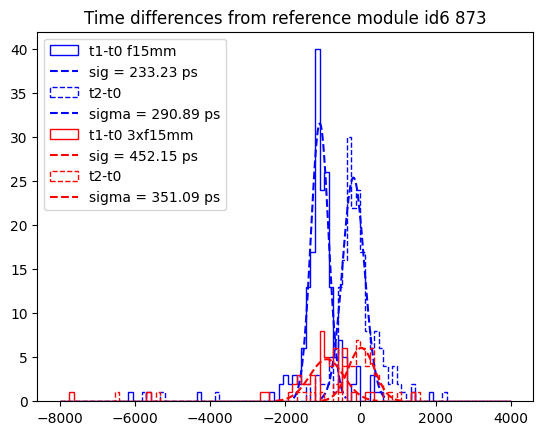

In [70]:

bins = np.linspace(-8000, 4000, 100)
bincenters = (bins[:-1] + bins[1:]) / 2

for dat, color, name in zip(filtered_doi_data, colors, names):
    ref_index = 105 + 768
    data = dat[dat[:, 1] == ref_index]
    mask = np.zeros(len(data), dtype=bool)
    for index in rough14micron_indices:
        mask = mask | (data[:, 5] == index)
        mask = mask | (data[:, 3] == get_compliment(index))
    data = data[mask]
    print(len(data))

    hist, _ = plt.hist(data[:, 7], bins=bins, color = color, histtype = 'step', label = f't1-t0 {name}')[0:2]
    popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [np.max(hist), bincenters[np.argmax(hist)], 100])
    plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 100)
    plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = color, linestyle = '--', label = 'sig = {:.2f} ps'.format(popt[2]))
    hist, _ = plt.hist(data[:, 8], bins=bins, color = color, histtype = 'step', linestyle = '--', label = 't2-t0')[0:2]
    popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [np.max(hist), bincenters[np.argmax(hist)], 100])
    plotting_bounds = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 100)
    plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = color, linestyle = '--', label = 'sigma = {:.2f} ps'.format(popt[2]))
plt.legend()
plt.title(f'Time differences from reference module id6 {ref_index}')
plt.show()
